In [88]:
import pandas as pd
import numpy as np

In [89]:
df= pd.read_csv(r"A:\Data analyst projects\Project_1_machine_prediction\predictive_maintenance.csv")

In [90]:
print(df.head())
print(df.info())
print(df.describe())
print("Shape:",df.shape)
print(df.columns)

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Target Failure Type  
0                    1551         42.8                0       0   No Failure  
1                    1408         46.3                3       0   No Failure  
2                    1498         49.4                5       0   No Failure  
3                    1433         39.5                7       0   No Failure  
4                    1408         40.0                9       0   No Failure  
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 column

In [91]:
for col in df.select_dtypes(include='str').columns:
    print(f"\n{col}:")
    print(df[col].unique())


Product ID:
<ArrowStringArray>
['M14860', 'L47181', 'L47182', 'L47183', 'L47184', 'M14865', 'L47186',
 'L47187', 'M14868', 'M14869',
 ...
 'L57170', 'M24851', 'L57172', 'L57173', 'L57174', 'M24855', 'H39410',
 'M24857', 'H39412', 'M24859']
Length: 10000, dtype: str

Type:
<ArrowStringArray>
['M', 'L', 'H']
Length: 3, dtype: str

Failure Type:
<ArrowStringArray>
[              'No Failure',            'Power Failure',
        'Tool Wear Failure',       'Overstrain Failure',
          'Random Failures', 'Heat Dissipation Failure']
Length: 6, dtype: str


In [92]:
df.select_dtypes(include='str').apply(lambda x: x.unique())


Product ID      [M14860, L47181, L47182, L47183, L47184, M1486...
Type                                                    [M, L, H]
Failure Type    [No Failure, Power Failure, Tool Wear Failure,...
dtype: object

In [93]:
# To know the unique failure types
print(df['Failure Type'].unique())

# To know the total number of unique failure types
print("total_unique_values:", df['Failure Type'].nunique())

# to know how many records belong to each failure type:
print(df['Failure Type'].value_counts())


<ArrowStringArray>
[              'No Failure',            'Power Failure',
        'Tool Wear Failure',       'Overstrain Failure',
          'Random Failures', 'Heat Dissipation Failure']
Length: 6, dtype: str
total_unique_values: 6
Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64


In [94]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

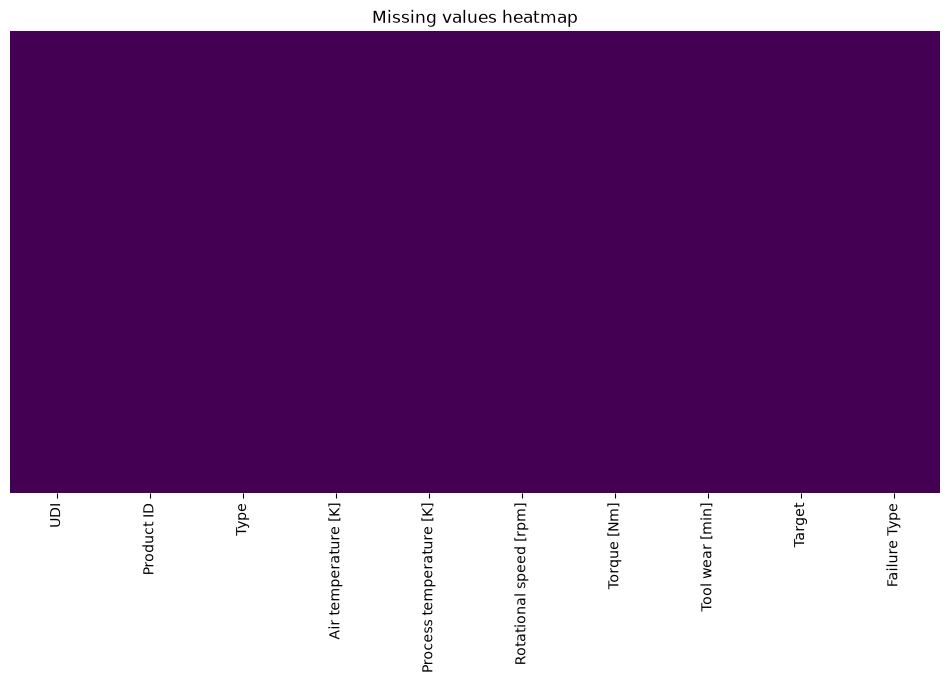

In [95]:
# Missing values heatmap
plt.figure(figsize = (12,6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False,cmap='viridis')
plt.title('Missing values heatmap')
plt.show()

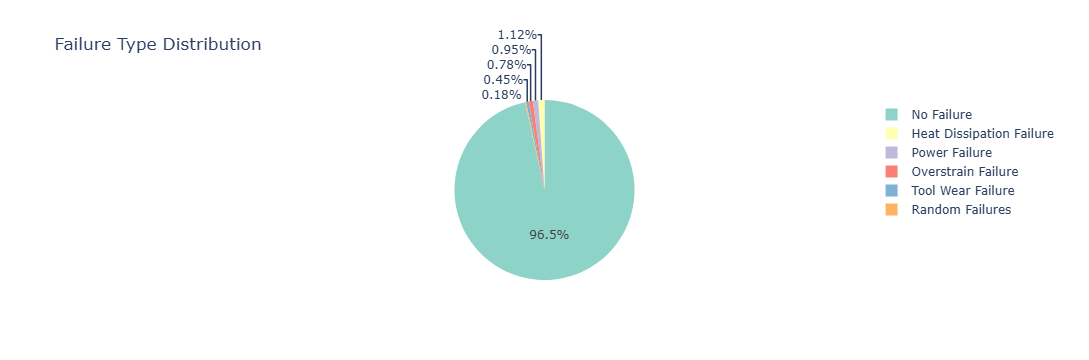

In [96]:
# Failure distrubution
fig = px.pie(df, names='Failure Type', title = 'Failure Type Distribution', color_discrete_sequence = px.colors.qualitative.Set3)
fig.show()

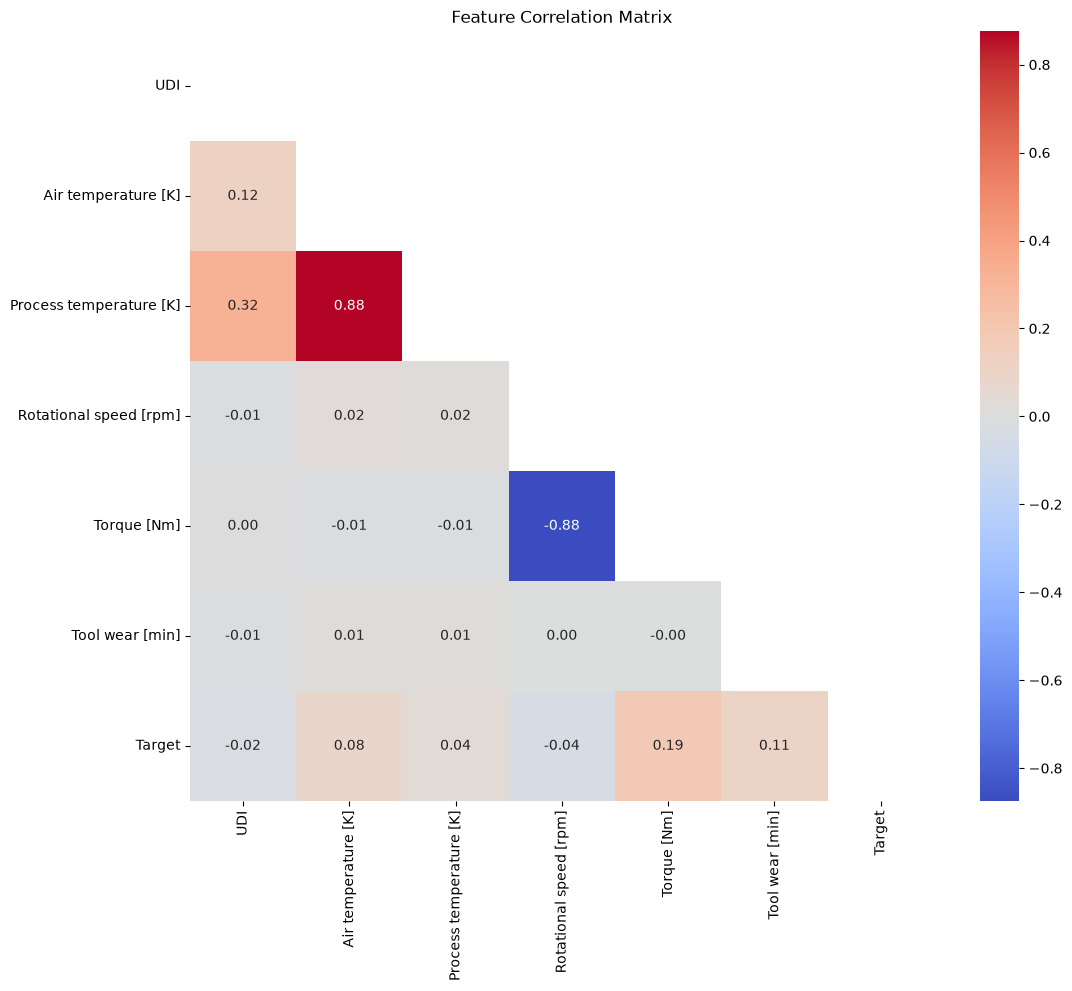

In [97]:
# Correlation Heatmap
corr_mat = df.select_dtypes(include='number').corr()
my_mask = np.triu(np.ones_like(corr_mat, dtype = bool))
fig, axes = plt.subplots(figsize = (12,10))
sns.heatmap(corr_mat, mask = my_mask , annot = True, fmt='.2f', cmap='coolwarm',center=0, ax=axes)
plt.title('Feature Correlation Matrix')
plt.show()

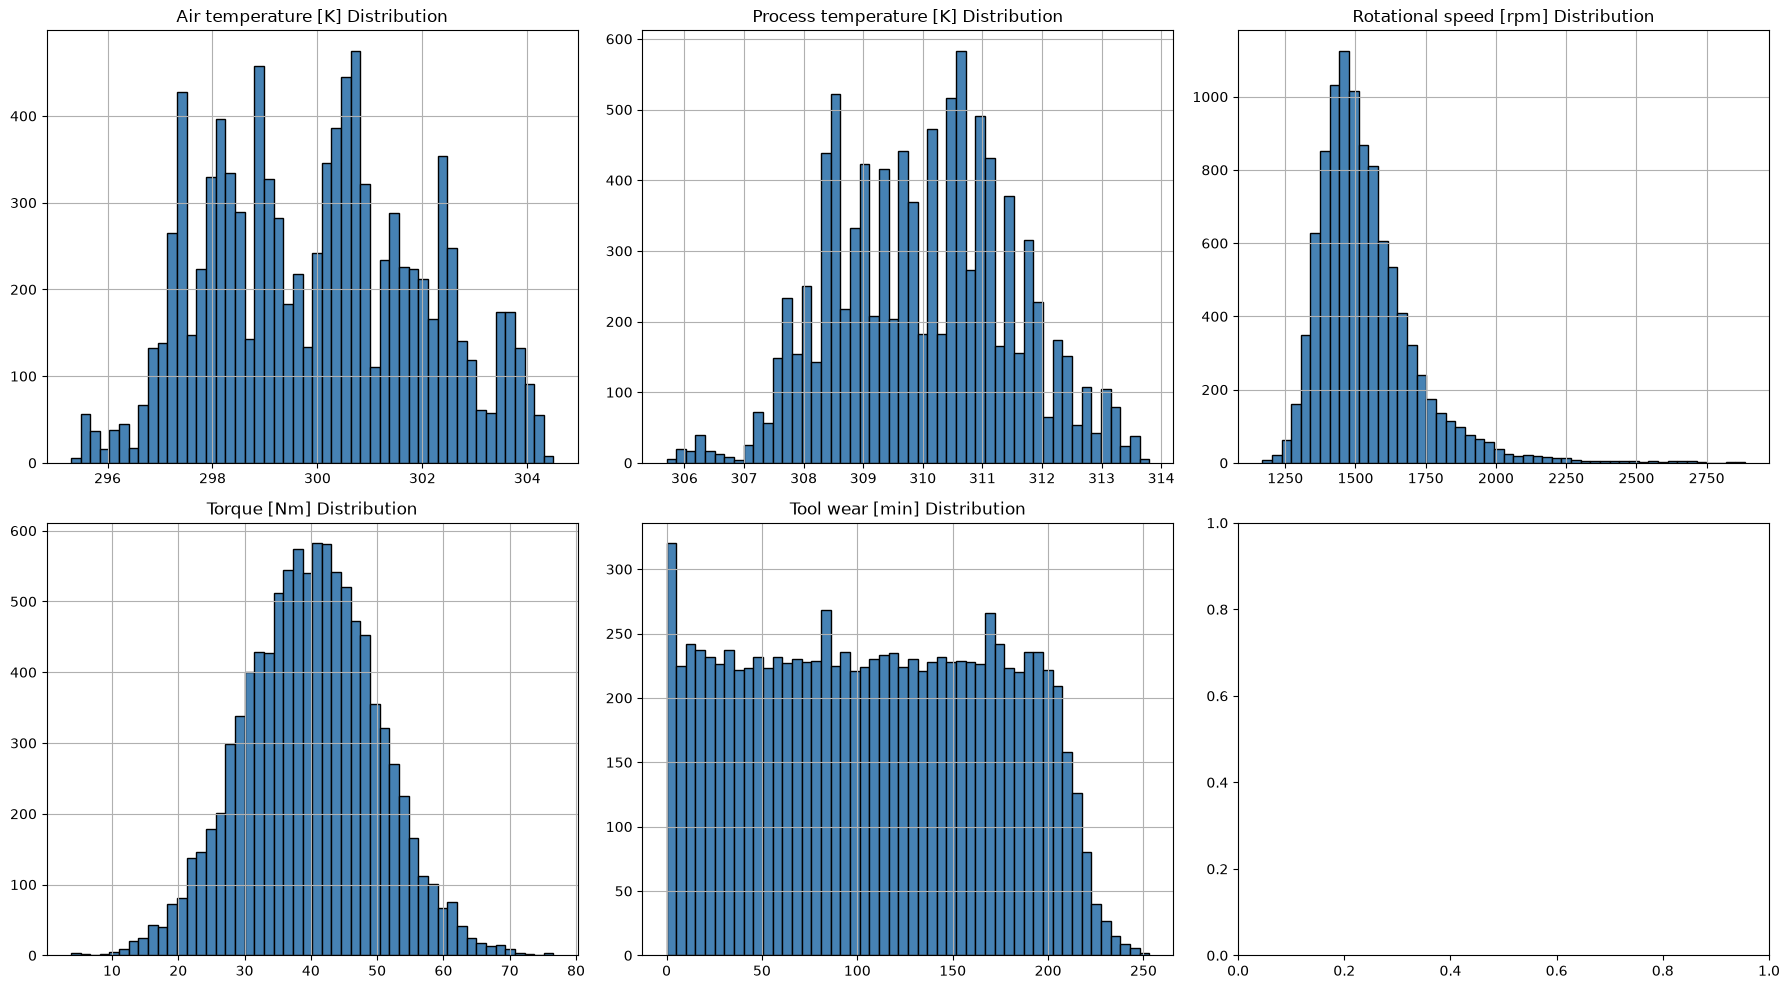

In [98]:
# 4. Distribution plots for each feature
features = ['Air temperature [K]', 
            'Process temperature [K]',
            'Rotational speed [rpm]',
            'Torque [Nm]',
            'Tool wear [min]']

fig, axes = plt.subplots(2,3, figsize=(18,10))
for i, col in enumerate(features):
    ax = axes[i//3, i%3]
    df[col].hist(bins=50, ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'{col} Distribution')
plt.tight_layout()
plt.show()

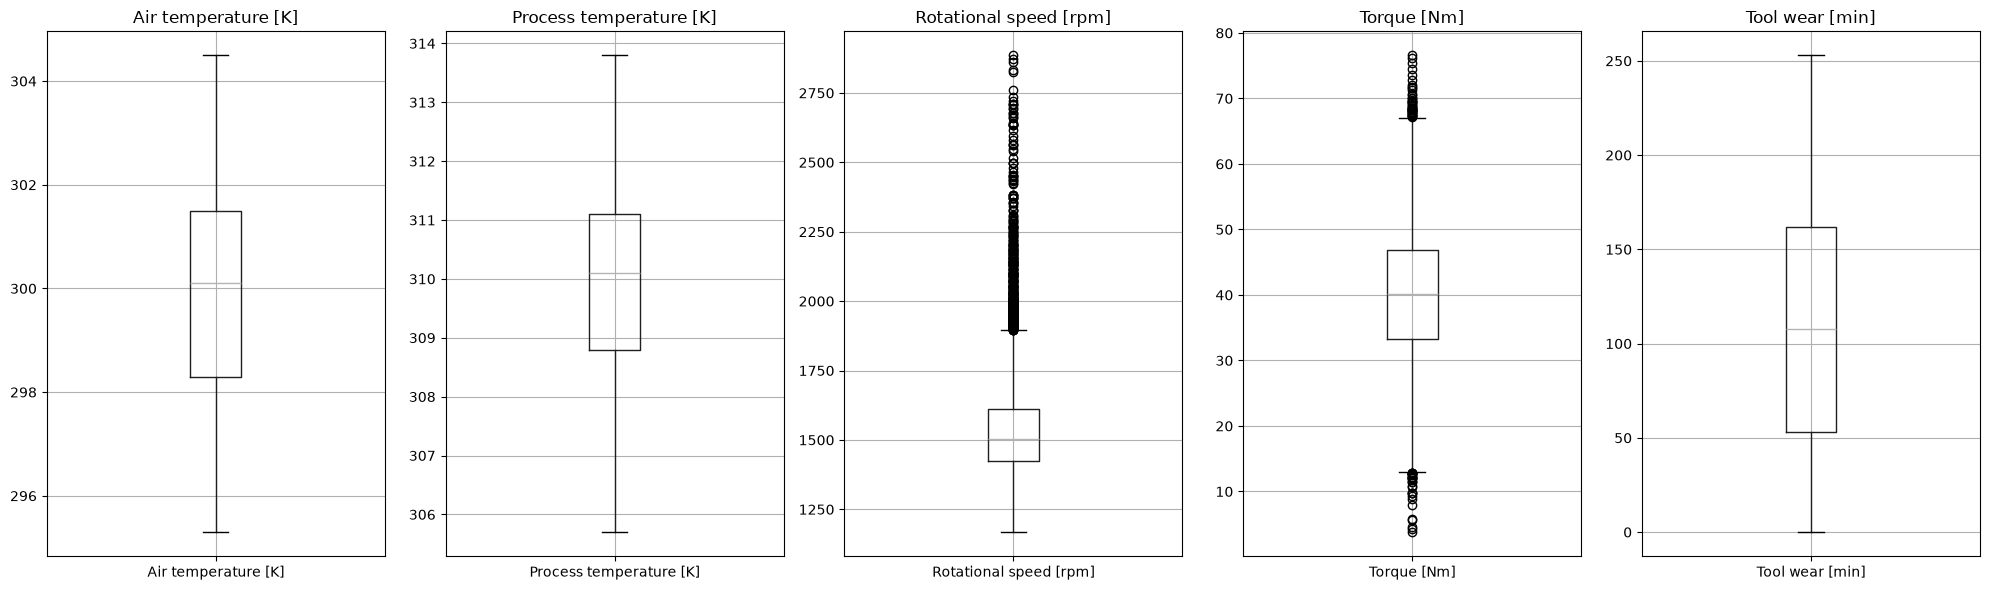

In [99]:
# 5. Box plots — outlier detection
fig, axes = plt.subplots(1,5, figsize=(20,6))
for i, col in enumerate(features):
    df.boxplot(column = col, ax= axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

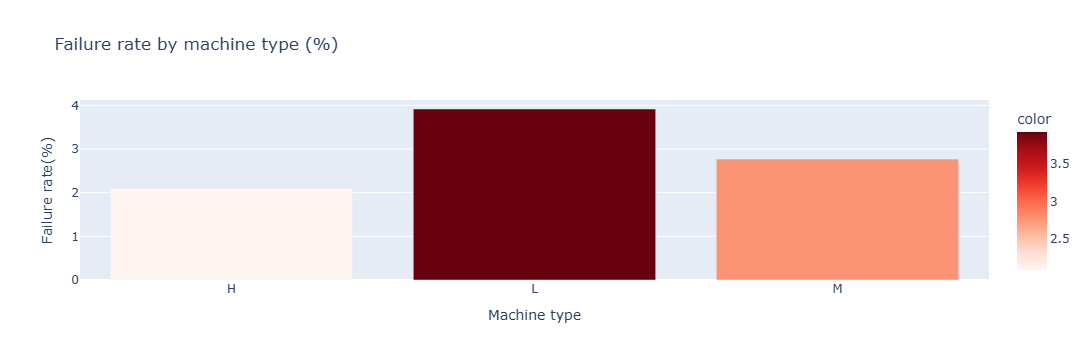

In [100]:
# 6. Failure rate by machine type
failure_rate = df.groupby('Type')['Target'].mean()*100
fig = px.bar(x=failure_rate.index, y=failure_rate.values, title='Failure rate by machine type (%)',
             labels={'x':'Machine type', 'y':'Failure rate(%)'}, color=failure_rate.values, color_continuous_scale='Reds')
fig.show()

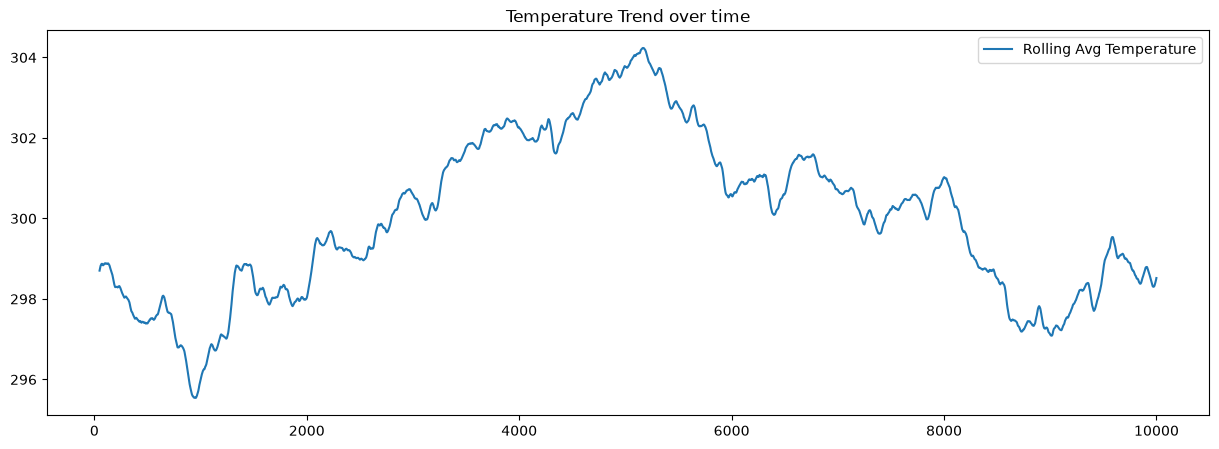

In [101]:
# 7. Time-based analysis
df['rolling_temp'] = df['Air temperature [K]'].rolling(50).mean()
plt.figure(figsize=(15,5))
plt.plot(df['rolling_temp'], label = 'Rolling Avg Temperature')
plt.title('Temperature Trend over time')
plt.legend()
plt.show()

In [102]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [103]:
# Feature Engineering — creating new features
df['temp_diff'] = (df['Process temperature [K]'] - df['Air temperature [K]'])
df['power'] = (df['Rotational speed [rpm]'] * df['Torque [Nm]'])
df['tool_wear_rate'] = (df['Tool wear [min]'] / (df['Rotational speed [rpm]'] + 1))
df['heat_dissipation'] = (df['temp_diff'] * df['Rotational speed [rpm]'])
print(df.head())
                        

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Target Failure Type  \
0                    1551         42.8                0       0   No Failure   
1                    1408         46.3                3       0   No Failure   
2                    1498         49.4                5       0   No Failure   
3                    1433         39.5                7       0   No Failure   
4                    1408         40.0                9       0   No Failure   

   rolling_temp  temp_diff    power  tool_wear_rate  heat_dissipation  
0           Na

In [104]:
# Removing outliers using IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 -Q1
    return df[~((df[column] < Q1-1.5*IQR) | (df[column] > Q3 + 1.5*IQR))]
for col in features:
    df = remove_outliers(df,col)

print(df.shape)

(9535, 15)


In [105]:
# Encoding
encoder = LabelEncoder()
df['Type_encoded'] = encoder.fit_transform(df['Type']) 
print(df.head())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Target Failure Type  \
0                    1551         42.8                0       0   No Failure   
1                    1408         46.3                3       0   No Failure   
2                    1498         49.4                5       0   No Failure   
3                    1433         39.5                7       0   No Failure   
4                    1408         40.0                9       0   No Failure   

   rolling_temp  temp_diff    power  tool_wear_rate  heat_dissipation  \
0           N

In [106]:
# Feature selection
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

X = df[features + ['temp_diff', 'power', 'tool_wear_rate', 'Type_encoded']]
y = df['Target']

In [107]:
# 5. Handling imbalanced data using SMOTE
smote = SMOTE(random_state = 42)
X_balanced , y_balanced = smote.fit_resample(X,y)

In [108]:
# Scale Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_balanced)

In [109]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_balanced, test_size = 0.2, random_state = 42, stratify = y_balanced)

In [110]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [111]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier)
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score)

import warnings
warnings.filterwarnings('ignore')

result={}
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree' : DecisionTreeClassifier(random_state=42),
    'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting' : GradientBoostingClassifier(random_state=42),
    'XGBoost' : XGBClassifier(random_state=42, eval_metric='logloss'),
    'SVM' : SVC(probability=True, random_state=42)
}

results={}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    results[name] = { 'Accuracy': accuracy_score(y_test, y_pred), 
                      'ROC-AUC' : roc_auc_score(y_test, y_prob),
                      'Model': model }
    print(f"\n{name}:")
    print(classification_report(y_test, y_pred))
    

                      
    


Logistic Regression:
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1855
           1       0.83      0.87      0.85      1854

    accuracy                           0.85      3709
   macro avg       0.85      0.85      0.85      3709
weighted avg       0.85      0.85      0.85      3709


Decision Tree:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      1855
           1       0.94      0.96      0.95      1854

    accuracy                           0.95      3709
   macro avg       0.95      0.95      0.95      3709
weighted avg       0.95      0.95      0.95      3709


Random Forest:
              precision    recall  f1-score   support

           0       0.99      0.96      0.98      1855
           1       0.96      0.99      0.98      1854

    accuracy                           0.98      3709
   macro avg       0.98      0.98      0.98      3709
weighted avg       0

In [112]:
# Compare results
results_df = pd.DataFrame(results).T
print(results_df[['Accuracy', 'ROC-AUC']].sort_values('ROC-AUC', ascending = False))

                     Accuracy   ROC-AUC
XGBoost              0.989755  0.999487
Random Forest        0.976274  0.997572
Gradient Boosting    0.935293  0.985123
SVM                  0.928013   0.97728
Decision Tree        0.947695  0.947698
Logistic Regression  0.848477  0.926331


In [113]:
# Select best model
best_model_name = results_df['ROC-AUC'].astype(float).idxmax()
best_model = results[best_model_name]['Model']
print(f"\nBest Model: {best_model_name}")


Best Model: XGBoost


In [114]:
# Hyperparameter Tuning when you know the best model name
from sklearn.model_selection import GridSearchCV

# XGBoost Model
xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

# Defining Hyperparameters
param_grid = {
    'n_estimators' : [100,200,300],
    'max_depth' : [3,5,7],
    'learning_rate' : [0.01, 0.1, 0.2]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid = param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

# Hyperparameter tuning
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(grid_search.best_params_)

# Best CV score
print("\nBest CV ROC-AUC:")
print(grid_search.best_score_)

# Final tuned model
best_xgb = grid_search.best_estimator_

Best Parameters:
{'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300}

Best CV ROC-AUC:
0.9995863269798052


In [115]:
# Hyperparameter Tuning for Automatically Selected Best Model

from sklearn.model_selection import GridSearchCV

# 1. Automatically select the best model
best_model_name = results_df['ROC-AUC'].astype(float).idxmax()
best_model = results[best_model_name]['Model']
print(f"Selected Best Model: {best_model_name}")

# 2. Define hyperparameter grids for all models
param_grids = {
    'XGBoost' : {
        'n_estimators' : [100,200,300],
        'max_depth' : [3,5,7],
        'learning_rate' : [0.01,0.1,0.2]
    },

    'Random forest' : {
        'n_estimators' : [100,200,300],
        'max_depth' : [5,10,20],
        'min_samples_split' : [2,5],
        'min_samples_leaf' : [1,2]
    },

    'Gradient Boosting' : {
        'n_estimators' : [100,200,300],
        'max_depth' : [3,5,7],
        'learning_rate' : [0.01, 0.1, 0.2]
    },

    'SVM' : {
        'C' : [0.1, 1, 10],
        'gamma' : ['scale', 'auto'],
        'kernel' : ['rbf', 'linear']
    },

    'Decision Tree' : {
        'max_depth' : [3,5,10,20, None],
        'min_samples_split' : [2,5,10],
        'min_samples_leaf' : [1,2,4]
    },

    'Logistic Regression' : {
        'C' : [0.01, 1, 10, 100],
        'solver' : ['liblinear', 'lbfgs']
    }

}

# 3. Automatically get the parameter grid corresponding to the selected best model
param_grid = param_grids[best_model_name]

# 4. Create GridSearchCV
grid_search = GridSearchCV(
    estimator=best_model,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

# 5. Perform hyperparameter tuning
grid_search.fit(X_train, y_train)

# 7. Display best cross-validation ROC-AUC
print("\nBest CV ROC-AUC:")
print(grid_search.best_score_)

# 8. Get final tuned model
best_tuned_model = grid_search.best_estimator_
        



Selected Best Model: XGBoost

Best CV ROC-AUC:
0.9995863269798052


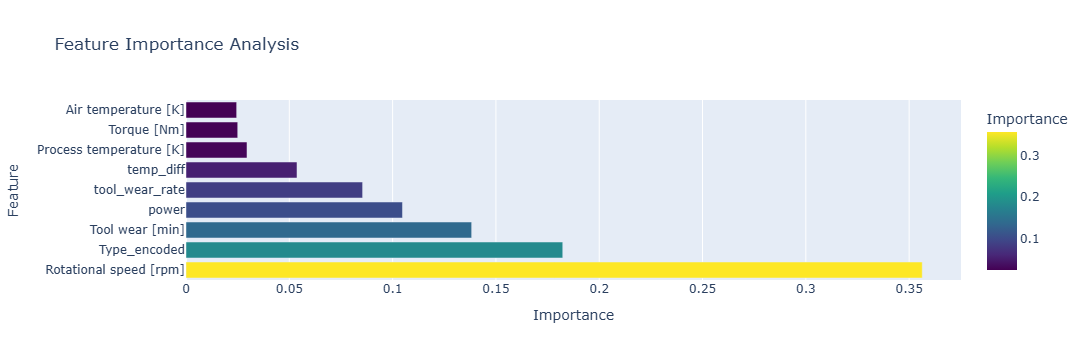

In [116]:
# Advanced Analysis
importances = best_tuned_model.feature_importances_
feature_names = X.columns
feat_imp = pd.DataFrame({
    'Feature' : feature_names,
    'Importance' : importances}).sort_values('Importance', ascending=False)
fig = px.bar(feat_imp, x='Importance', y='Feature', orientation='h', title='Feature Importance Analysis',
             color='Importance', color_continuous_scale = 'Viridis')
fig.show()

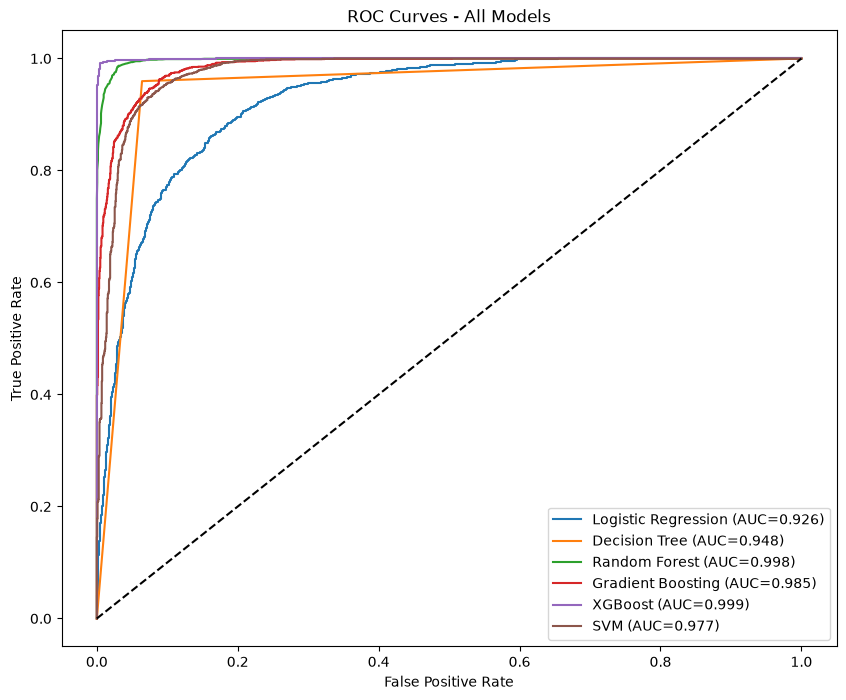

In [117]:
# RoC-Curve
plt.figure(figsize=(10,8))
for name, result in results.items():
    model = result['Model']
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend()
plt.show()

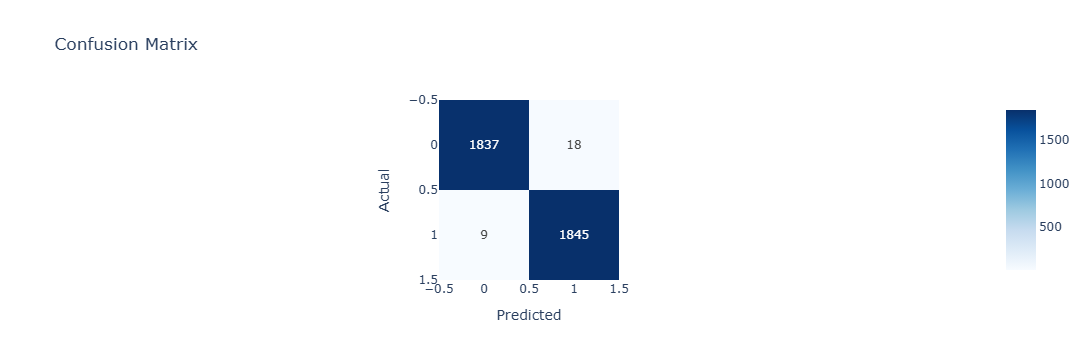

In [118]:
# 3. Confusion Matrix — best model
cm = confusion_matrix(y_test, best_tuned_model.predict(X_test))
fig = px.imshow(cm, text_auto = True, title = 'Confusion Matrix',
               labels= dict(x="Predicted", y="Actual"), color_continuous_scale='Blues')
fig.show()
                     

In [119]:
# 4. Financial Impact Analysis

cost_per_failure = 50000
cost_per_false_alarm = 5000

y_pred_best = best_tuned_model.predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best).ravel()

financial_impact = (fn * cost_per_failure + 
                    fp * cost_per_false_alarm)
savings = fn * cost_per_failure

print(f"\nFinancial Analysis:")
print(f"Undetected Failures: {fn}")
print(f"False Alarms: {fp}")
print(f"Potential Loss: ₹{financial_impact:,}")
print(f"Savings vs No Model: ₹{savings:,}")


Financial Analysis:
Undetected Failures: 9
False Alarms: 18
Potential Loss: ₹540,000
Savings vs No Model: ₹450,000


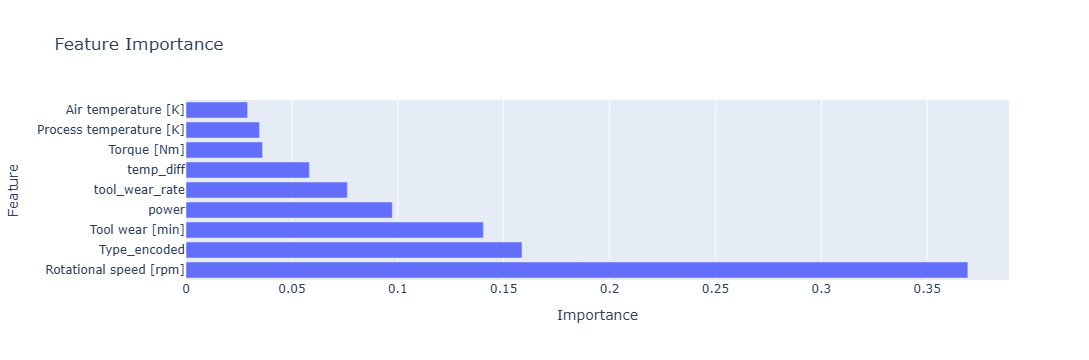

In [120]:
# Advanced Analysis
# 1. Feature Importance

importances = best_model.feature_importances_
feat_imp = pd.DataFrame({
    'Feature' : X.columns,
    'Importance' : importances
}).sort_values('Importance' , ascending = False)

import plotly.express as px
fig = px.bar(feat_imp,
             x='Importance',
             y='Feature',
             orientation='h',
             title = 'Feature Importance')
fig.show()




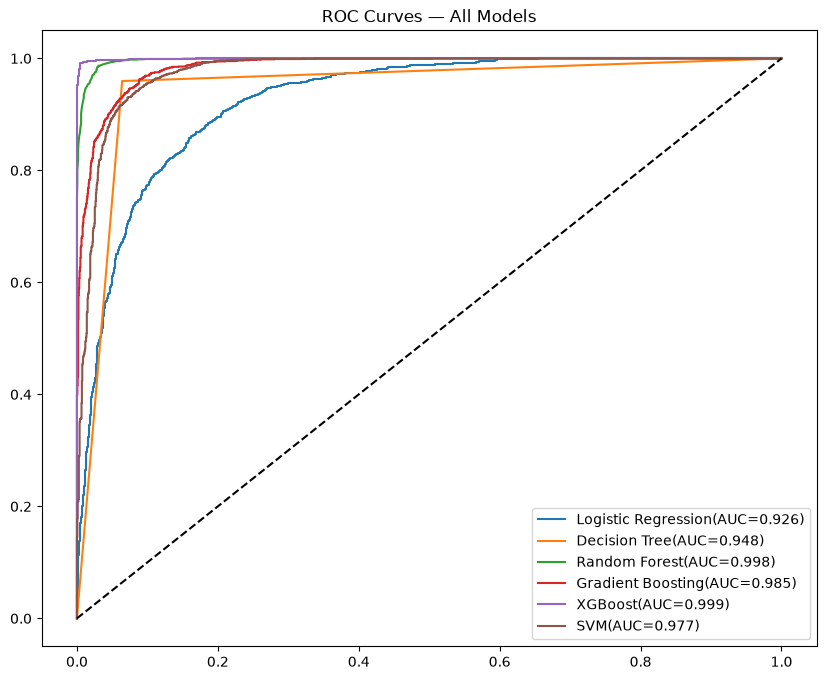

In [121]:
# 2. ROC Curve — all models
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
for name, result in results.items():
    model = result['Model']
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name}(AUC={auc:.3f})')

plt.plot([0,1],[0,1], 'k--')
plt.title('ROC Curves — All Models')
plt.legend()
plt.show()

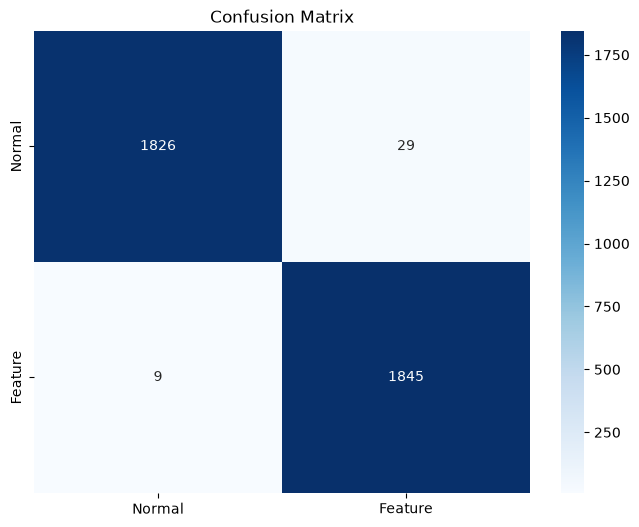

In [122]:
# 3. Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, best_model.predict(X_test))
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
           cmap='Blues', 
           xticklabels=['Normal','Feature'],
           yticklabels=['Normal', 'Feature'])
plt.title('Confusion Matrix')
plt.show()

            

In [144]:
import pickle

# Sahi order mein save karo
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_tuned_model, f)

with open('data_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Saved correctly!")

# Verify karo
with open('best_model.pkl', 'rb') as f:
    check_model = pickle.load(f)

with open('data_scaler.pkl', 'rb') as f:
    check_scaler = pickle.load(f)

print(f"Model type: {type(check_model)}")
print(f"Scaler type: {type(check_scaler)}")

✅ Saved correctly!
Model type: <class 'xgboost.sklearn.XGBClassifier'>
Scaler type: <class 'sklearn.preprocessing._data.StandardScaler'>


In [145]:
# Logging setup
import logging
logging.basicConfig(
    level=logging.INFO, 
    format = '%(asctime)s | %(levelname)s | %(message)s',
    handlers = [
        logging.FileHandler('manufacturing.log'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)
logger.info("System Started")
print("Logging Done")

2026-09-08 17:16:16,681 | INFO | System Started


Logging Done


In [146]:
# Email Alert Function
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
from datetime import datetime

def send_email_alert(machine_id, failure_prob):
    sender="enter sender mail"
    receiver="enter your mail"
    app_password = "enter password"

    msg = MIMEMultipart()
    msg['From'] = sender
    msg['To'] = receiver
    msg['Subject'] = f"ALERT: Machine {machine_id} High Risks!"
    body = f"""
PREDICTIVE MAINTENANCE ALERT
==============================
Machine ID   : {machine_id}
Failure Risk : {failure_prob:.1%}
Time         : {datetime.now()}
Action       : IMMEDIATE MAINTENANCE NEEDED
    """

    msg.attach(MIMEText(body, 'plain'))
    with smtplib.SMTP('smtp.gmail.com', 587) as server:
        server.starttls()
        server.login(sender, app_password)
        server.send_message(msg)

    print(f"Email send for Machine {machine_id}!")
    logger.info(f"Alert send: Machine {machine_id}!")
    
send_email_alert("M-001", 0.85)


2026-09-08 17:16:22,621 | INFO | Alert send: Machine M-001!


Email send for Machine M-001!


In [147]:
%pip install python-telegram-bot

Note: you may need to restart the kernel to use updated packages.


In [148]:
from telegram import Bot
from datetime import datetime

async def send_telegram(machine_id, failure_prob):

    # Telegram credentials
    bot_token = "enter bot token"
    chat_id = "enter_chat_id"

    # Create bot
    bot = Bot(token=bot_token)

    # Select alert emoji
    emoji = "🔴" if failure_prob > 0.7 else "🟡"

    # Create message
    message = f"""
{emoji} MANUFACTURING ALERT

Machine ID   : {machine_id}
Failure Risk : {failure_prob:.1%}
Time         : {datetime.now().strftime('%H:%M:%S')}
Action       : {'IMMEDIATE!' if failure_prob > 0.7 else 'Monitor closely'}
"""

    # Send Telegram message
    await bot.send_message(
        chat_id=chat_id,
        text=message
    )

    print(f"Telegram sent: Machine {machine_id}!")


# Test in Jupyter Notebook
await send_telegram("M-001", 0.85)

2026-09-08 17:16:27,205 | INFO | HTTP Request: POST https://api.telegram.org/bot8917042456:AAFBDJ2MiicNSDEm9GbXiTRNvfvYURBNvbE/sendMessage "HTTP/1.1 200 OK"


Telegram sent: Machine M-001!


In [149]:
# Excel Report Generator
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment

def generate_excel_report(predictions_df):
    filename = f"report_{datetime.now().strftime('%Y%m%d_%H%M')}.xlsx"

    wb = openpyxl.Workbook()
    ws = wb.active
    ws.title = "Daily Report"

    # Title
    ws.merge_cells('A1:F1')
    ws['A1'] = f"Manufacturing Report — {datetime.now().strftime('%d %b %Y')}"
    ws['A1'].font = Font(bold=True, size=14, color='FFFFFF')
    ws['A1'].fill = PatternFill(fill_type='solid', fgColor='0A1628')
    ws['A1'].alignment = Alignment(horizontal='center')

    # Headers
    headers = ['Machine ID', 'Risk Level',
               'Failure Prob', 'Action',
               'Air Temp', 'Tool Wear']

    for col, header in enumerate(headers, 1):
        cell = ws.cell(row=2, column=col, value=header)
        cell.font = Font(bold=True, color='FFFFFF')
        cell.fill = PatternFill(fill_type='solid', fgColor='1D7A5F')

    # Data
    for row_idx, (_, row) in enumerate(
            predictions_df.iterrows(), 3):
        prob = row.get('Failure_Probability', 0)
        ws.append([
            row.get('Machine_ID', f'M-{row_idx}'),
            str(row.get('Risk_Level', 'Low')),
            f"{prob:.1%}",
            'IMMEDIATE' if prob > 0.7 else
            'MONITOR' if prob > 0.3 else 'NORMAL',
            round(row.get('Air temperature [K]', 0), 1),
            round(row.get('Tool wear [min]', 0), 0)
        ])

    wb.save(filename)
    print(f"Report saved: {filename}")
    return filename

generate_excel_report(results_df)

Report saved: report_20260908_1716.xlsx


'report_20260908_1716.xlsx'

In [150]:
%whos DataFrame

Variable     Type         Data/Info
-----------------------------------
X            DataFrame    Shape: (9535, 9)
X_balanced   DataFrame    Shape: (18544, 9)
corr_mat     DataFrame    Shape: (7, 7)
df           DataFrame    Shape: (9535, 16)
feat_imp     DataFrame    Shape: (9, 2)
results_df   DataFrame    Shape: (6, 3)


In [151]:
import os

print(os.path.abspath("report_20260907_2345.xlsx"))

C:\Users\anura\report_20260907_2345.xlsx


In [152]:
import os

os.startfile("report_20260907_2345.xlsx")

In [153]:
import pickle

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("scaler.pkl created successfully!")

scaler.pkl created successfully!


In [154]:
import os

print(os.path.exists('scaler.pkl'))

True


In [155]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\anura
['# Data cleaning in pandas.ipynb', '.anaconda', '.android', '.apio', '.arduinoIDE', '.cache', '.codex', '.conda', '.condarc', '.config', '.continuum', '.copilot', '.gemini', '.gitconfig', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.local', '.matplotlib', '.opera', '.packettracer', '.platformio', '.vscode', '.vscode-shared', '.wokwi', '.Xilinx', '1stnotebook.ipynb', 'Amazon Web Scraper project.ipynb', 'AmazonWebScraperDataset.csv', 'ansel', 'Anurag1', 'AppData', 'Application Data', 'arbitary_keyword.ipynb', 'best_model.pkl', 'BMI_calculator.ipynb', 'Cisco Packet Tracer 9.0.1', 'Cookies', 'CrossDevice', 'Data_cleaning_in_pandas.ipynb', 'data_scaler.pkl', 'data_scraping1.ipynb', 'Desktop', 'Documents', 'Downloads', 'EDA_in_pandas.ipynb', 'Favorites', 'file sorter.ipynb', 'Filtering-and-ordering.ipynb', 'group_by_and_aggregating_in _pandas.ipynb', 'How to use an API + API Test Notebook.ipynb', 'Indexing.ipynb', 'Links', 'Local Settings', 'machine_prediction.i

In [156]:
import os

matches = []

for root, dirs, files in os.walk(r"C:\Users\anura"):
    for file in files:
        if file.lower().endswith(".csv"):
            matches.append(os.path.join(root, file))

for file in matches:
    print(file)

C:\Users\anura\AmazonWebScraperDataset.csv
C:\Users\anura\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\numpy\random\tests\data\mt19937-testset-1.csv
C:\Users\anura\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\numpy\random\tests\data\mt19937-testset-2.csv
C:\Users\anura\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\numpy\random\tests\data\pcg64-testset-1.csv
C:\Users\anura\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\numpy\random\tests\data\pcg64-testset-2.csv
C:\Users\anura\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\numpy\random\tests\data\pcg64dxsm-testset-1.csv
C:\Users\anura\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\numpy\random\tests\data\pcg64dxsm-testset-2.csv
C:\Users\anura\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\nu

In [157]:
%whos DataFrame

Variable     Type         Data/Info
-----------------------------------
X            DataFrame    Shape: (9535, 9)
X_balanced   DataFrame    Shape: (18544, 9)
corr_mat     DataFrame    Shape: (7, 7)
df           DataFrame    Shape: (9535, 16)
feat_imp     DataFrame    Shape: (9, 2)
results_df   DataFrame    Shape: (6, 3)


In [158]:
print(results_df.columns.tolist())

['Accuracy', 'ROC-AUC', 'Model']


In [159]:
def run_pipeline():
    print(f"\n🚀 Pipeline started: {datetime.now()}")
    logger.info("Pipeline starting...")

    # Updated names se load karo
    with open('best_model.pkl', 'rb') as f:
        model = pickle.load(f)

    with open('data_scaler.pkl', 'rb') as f:
        scaler = pickle.load(f)

    # Verify
    print(f"Model: {type(model).__name__}")
    print(f"Scaler: {type(scaler).__name__}")

    # Baaki code same rahega...

    # Load data
    df = pd.read_csv(r"A:\Data analyst projects\Project_1_machine_prediction\predictive_maintenance.csv")

    # Feature engineering
    df['temp_diff'] = (df['Process temperature [K]'] -
                       df['Air temperature [K]'])
    df['power'] = (df['Rotational speed [rpm]'] *
                   df['Torque [Nm]'])
    df['tool_wear_rate'] = (df['Tool wear [min]'] /
                            (df['Rotational speed [rpm]'] + 1))

    # ✅ Type_encoded add karo — yeh missing tha
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    df['Type_encoded'] = le.fit_transform(df['Type'])

    # Features — Type_encoded add kiya
    features = [
        'Air temperature [K]',
        'Process temperature [K]',
        'Rotational speed [rpm]',
        'Torque [Nm]',
        'Tool wear [min]',
        'temp_diff',
        'power',
        'tool_wear_rate',
        'Type_encoded'  # ✅ Yeh add kiya
    ]

    # Predict
    X_scaled = scaler.transform(df[features])
    df['Failure_Probability'] = \
        model.predict_proba(X_scaled)[:, 1]
    df['Risk_Level'] = pd.cut(
        df['Failure_Probability'],
        bins=[0, 0.3, 0.7, 1.0],
        labels=['Low', 'Medium', 'High']
    )
    df['Machine_ID'] = [f"M-{i:03d}"
                        for i in range(1, len(df)+1)]

    # High risk
    high_risk = df[df['Failure_Probability'] > 0.7]

    # Save results
    df.to_csv(
        f"predictions_{datetime.now().strftime('%Y%m%d_%H%M')}.csv",
        index=False
    )

    # Generate report
    generate_excel_report(df)

    print(f"✅ Done! High risk: {len(high_risk)}")
    logger.info(f"Pipeline complete. High risk: {len(high_risk)}")
    return df

# Test karo
result = run_pipeline()

2026-09-08 17:17:15,386 | INFO | Pipeline starting...



🚀 Pipeline started: 2026-09-08 17:17:15.386108
Model: XGBClassifier
Scaler: StandardScaler


2026-09-08 17:17:21,311 | INFO | Pipeline complete. High risk: 297


Report saved: report_20260908_1717.xlsx
✅ Done! High risk: 297


In [163]:
%pip install schedule

  Using cached schedule-1.2.2-py3-none-any.whl.metadata (3.8 kB)
Using cached schedule-1.2.2-py3-none-any.whl (12 kB)
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Set schedule
import schedule
import time

schedule.every().day.at("09:00").do(run_pipeline)
schedule.every().day.at("15:00").do(run_pipeline)
schedule.every(6).hours.do(run_pipeline)

print("✅ Scheduler started!")
print("Runs: 9AM | 3PM | Every 6 hours")
print("Ctrl+C to stop\n")

while True:
    schedule.run_pending()
    time.sleep(60)

✅ Scheduler started!
Runs: 9AM | 3PM | Every 6 hours
Ctrl+C to stop

